In [1]:
pin_file = r"C:\repositories\mokapot\data\phospho_rep1.pin"
fasta_file = r"C:\repositories\mokapot\data\human_sp_td.fasta"

In [2]:
import os
import mokapot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the random seed:
np.random.seed(42)

# Create an output directory
out_dir = "basic_python_api_output"
os.makedirs(out_dir, exist_ok=True)

In [3]:
import logging

# Change to True enable messages and nicely format them:
log = False
if log:
    logging.basicConfig(
        level=logging.INFO,
        format="%(levelname)s: %(message)s",
    )

In [4]:
psms = mokapot.read_pin(pin_file)

C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\mokapot\parsers\pin.py:238: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  yield psms.apply(pd.to_numeric, errors="ignore")


In [5]:
psms.add_proteins(fasta_file)

In [6]:
moka_conf, models = mokapot.brew(psms)
moka_conf.psms.head()

,SpecId,Label,ScanNr,ExpMass,CalcMass,Peptide,mokapot score,mokapot q-value,mokapot PEP,Proteins
0,target_0_51371_4_-1,True,51371,4051.1223,4051.1086,K.KLHEEEIQELQAQIQEQHVQIDVDVSKPDLTAALR.D,11.180948,0.000056,6.305117e-16,sp|P08670|VIME_HUMAN
1,target_0_48845_5_-1,True,48845,5269.5756,5269.5728,R.RGNVAGDSKNDPPMEAAGFTAQVIILNHPGQISAGYAPVLDCHT...,10.863262,0.000056,6.305117e-16,sp|P68104|EF1A1_HUMAN
2,target_0_41715_3_-1,True,41715,4473.8359,4473.8286,K.ALGKYGPADVEDTTGSGATDSKDDDDIDLFGS[79.97]DDEEE...,10.796913,0.000056,6.305117e-16,sp|P24534|EF1B_HUMAN
3,target_0_31886_3_-1,True,31886,3450.7612,3450.7544,R.AAAAVAAAASSCRPLGSGAGPGPTGAAPVSAPAPGPGPAGK.G,10.186580,0.000056,6.305117e-16,sp|Q9NRL3|STRN4_HUMAN
4,target_0_45243_4_-1,True,45243,3945.8759,3945.8706,R.CSDAAGYPHATHDLEGPPLDAYSIQGQHTISPLDLAK.L,10.165379,0.000056,6.305117e-16,sp|Q15365|PCBP1_HUMAN


In [7]:
moka_conf.peptides.head()

,SpecId,Label,ScanNr,ExpMass,CalcMass,Peptide,mokapot score,mokapot q-value,mokapot PEP,Proteins
0,target_0_51371_4_-1,True,51371,4051.1223,4051.1086,K.KLHEEEIQELQAQIQEQHVQIDVDVSKPDLTAALR.D,11.180948,0.000077,6.305117e-16,sp|P08670|VIME_HUMAN
1,target_0_48845_5_-1,True,48845,5269.5756,5269.5728,R.RGNVAGDSKNDPPMEAAGFTAQVIILNHPGQISAGYAPVLDCHT...,10.863262,0.000077,6.305117e-16,sp|P68104|EF1A1_HUMAN
2,target_0_41715_3_-1,True,41715,4473.8359,4473.8286,K.ALGKYGPADVEDTTGSGATDSKDDDDIDLFGS[79.97]DDEEE...,10.796913,0.000077,6.305117e-16,sp|P24534|EF1B_HUMAN
3,target_0_31886_3_-1,True,31886,3450.7612,3450.7544,R.AAAAVAAAASSCRPLGSGAGPGPTGAAPVSAPAPGPGPAGK.G,10.186580,0.000077,6.305117e-16,sp|Q9NRL3|STRN4_HUMAN
4,target_0_45243_4_-1,True,45243,3945.8759,3945.8706,R.CSDAAGYPHATHDLEGPPLDAYSIQGQHTISPLDLAK.L,10.165379,0.000077,6.305117e-16,sp|Q15365|PCBP1_HUMAN


In [8]:
moka_conf.proteins.head()

,mokapot protein group,best peptide,stripped sequence,mokapot score,mokapot q-value,mokapot PEP
0,sp|P08670|VIME_HUMAN,K.KLHEEEIQELQAQIQEQHVQIDVDVSKPDLTAALR.D,KLHEEEIQELQAQIQEQHVQIDVDVSKPDLTAALR,11.180948,0.000291,6.305117e-16
1,sp|P68104|EF1A1_HUMAN,R.RGNVAGDSKNDPPMEAAGFTAQVIILNHPGQISAGYAPVLDCHT...,RGNVAGDSKNDPPMEAAGFTAQVIILNHPGQISAGYAPVLDCHTAH...,10.863262,0.000291,6.305117e-16
2,sp|P24534|EF1B_HUMAN,K.ALGKYGPADVEDTTGSGATDSKDDDDIDLFGS[79.97]DDEEE...,ALGKYGPADVEDTTGSGATDSKDDDDIDLFGSDDEEESEEAK,10.796913,0.000291,6.305117e-16
3,sp|Q9NRL3|STRN4_HUMAN,R.AAAAVAAAASSCRPLGSGAGPGPTGAAPVSAPAPGPGPAGK.G,AAAAVAAAASSCRPLGSGAGPGPTGAAPVSAPAPGPGPAGK,10.186580,0.000291,6.305117e-16
4,sp|Q15365|PCBP1_HUMAN,R.CSDAAGYPHATHDLEGPPLDAYSIQGQHTISPLDLAK.L,CSDAAGYPHATHDLEGPPLDAYSIQGQHTISPLDLAK,10.165379,0.000291,6.305117e-16


In [9]:
tide_conf = psms.assign_confidence()

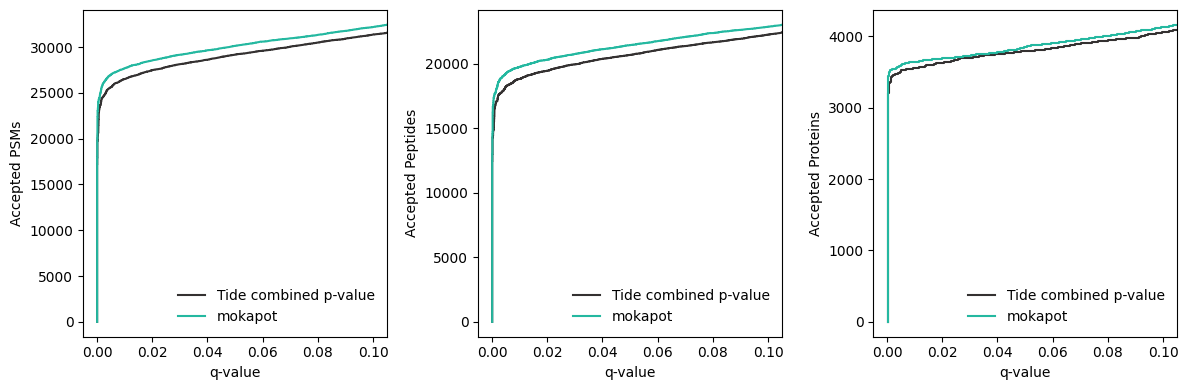

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
colors = ("#343131", "#24B8A0")

# Plot the performance:
for ax, level in zip(axs, tide_conf.levels):
    tide_conf.plot_qvalues(level=level, c=colors[0], ax=ax,
                           label="Tide combined p-value")
    moka_conf.plot_qvalues(level=level, c=colors[1], ax=ax,
                           label="mokapot")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [11]:
# PSMs
moka_psms = (moka_conf.psms["mokapot q-value"] <= 0.01).sum()
tide_psms = (tide_conf.psms["mokapot q-value"] <= 0.01).sum()
print(f"PSMs gained by mokapot: {moka_psms - tide_psms}")

# Peptides
moka_peps = (moka_conf.peptides["mokapot q-value"] <= 0.01).sum()
tide_peps = (tide_conf.peptides["mokapot q-value"] <= 0.01).sum()
print(f"Peptides gained by mokapot: {moka_peps - tide_peps}")

# Proteins
moka_prots = (moka_conf.proteins["mokapot q-value"] <= 0.01).sum()
tide_prots = (tide_conf.proteins["mokapot q-value"] <= 0.01).sum()
print(f"Proteins gained by mokapot: {moka_prots - tide_prots}")

PSMs gained by mokapot: 1169
Peptides gained by mokapot: 938
Proteins gained by mokapot: 89


In [12]:
result_files = moka_conf.to_txt(dest_dir=out_dir)
result_files

['basic_python_api_output\\mokapot.psms.txt',
 'basic_python_api_output\\mokapot.peptides.txt',
 'basic_python_api_output\\mokapot.proteins.txt']